In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import ttest_ind
import seaborn as sns
from statsmodels.regression.mixed_linear_model import MixedLM
from scipy.stats import mannwhitneyu, norm
from scipy.stats import wilcoxon


In [2]:
import plotly.express as px

# Import the following line to set Plotly as the default backend for pandas
pd.options.plotting.backend = "plotly"

In [3]:
dfs={}
relevent_subIds = {}
results_main={}
results_additional={}
relevent_subNums={}

In [4]:
relevant_columns = ['correctFirstRedPress',
       'correctFirstBluePress', 'incorrectRedPress', 'incorrectBluePress',
       'redChoice', 'blueChoice','correctFirstRedPressButtons',
       'correctFirstBluePressButtons', 'incorrectRedPressButtons',
       'incorrectBluePressButtons', 'redChoiceButtons', 'blueChoiceButtons',
       'correctFirstRedPressStar',
       'correctFirstBluePressStar', 'incorrectRedPressStar',
       'incorrectBluePressStar', 'redChoiceStar', 'blueChoiceStar',
       'allStars', 'howManyStars', 'correctFirstRedPressDevtest', 'correctFirstBluePressDevtest',
       'incorrectRedPressDevtest', 'incorrectBluePressDevtest', 'redChoiceDev',
       'blueChoiceDev']

In [5]:
info_table = pd.read_csv(r'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 2/subjects_info - sheet1.csv')
relevent_subIds[11] = info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subNums[11] = [info_table[(info_table.Experiment=='ST_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ST_DevL')&(info_table['isExperimentDone?']==1)].Name]
relevent_subIds[12] = info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subNums[12] = [info_table[(info_table.Experiment=='ST_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ST_DevR')&(info_table['isExperimentDone?']==1)].Name]
relevent_subIds[13] = info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subNums[13] = [info_table[(info_table.Experiment=='ET_DevL2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ET_DevL')&(info_table['isExperimentDone?']==1)].Name]
relevent_subIds[14] = info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subNums[14] = [info_table[(info_table.Experiment=='ET_DevR2p')&(info_table['isExperimentDone?']==1)].WorkerId, info_table[(info_table.Experiment=='ET_DevR')&(info_table['isExperimentDone?']==1)].Name]

In [6]:
for i in range(11, 15):
    df = pd.read_json(rf'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 2/results_{i}.json')
    dfs[i] = df.rename(columns={'redChoiceButtons': 'blueChoiceButtons', 'blueChoiceButtons': 'redChoiceButtons'})

In [7]:
import copy

def get_corrected_presses(row, correct_col, choice_col):
    correct_presses = row[correct_col]
    choices = row[choice_col]

    # Ensure values are lists, otherwise return NaN
    if not isinstance(correct_presses, list) or not isinstance(choices, list):
        return np.nan
    
    corrected = []
    for choice in choices:
        valid_presses = [p for p in correct_presses if p <= choice + 1000 and p > choice]
        if len(valid_presses) > 0:
            corrected.append(valid_presses[0])  # Take the first valid press
            
    return corrected if len(corrected) > 0 else np.nan

def correct_first_press(dfs):
    """
    Fix incorrect first press data by ensuring it is the first press within 1000ms of a choice.
    """
    corrected_dfs = dict()
    
    # Define column pairs to process
    column_pairs = [
        ("correctFirstRedPress", "redChoice"),
        ("correctFirstBluePress", "blueChoice"),
        ("correctFirstRedPressButtons", "redChoiceButtons"),
        ("correctFirstBluePressButtons", "blueChoiceButtons"),
        ("correctFirstRedPressStar", "redChoiceStar"),
        ("correctFirstBluePressStar", "blueChoiceStar"),
        ("correctFirstRedPressDevtest", "redChoiceDev"),
        ("correctFirstBluePressDevtest", "blueChoiceDev")
    ]

    for i, df in dfs.items():
        tmp = copy.deepcopy(df)
        for correct_col, choice_col in column_pairs:
            if correct_col in df.columns and choice_col in df.columns:
                # Apply the correction
                tmp[correct_col] = tmp.apply(get_corrected_presses, axis=1, args=(correct_col, choice_col))
        corrected_dfs[i] = tmp
    
    return corrected_dfs

In [8]:
dfs_new = correct_first_press(dfs)
del dfs
dfs = copy.deepcopy(dfs_new)
del dfs_new

In [9]:
for i in range(11, 15):
    df = dfs[i]
    results_main[i] = df[df.subId.isin(relevent_subIds[i])]\
    .set_index(['subId',df[df.subId.isin(relevent_subIds[i])].createdAt.str[:10]])[relevant_columns]\
    .apply(lambda row: [len(x) if isinstance(x,list) else 0 for x in row], axis=1, result_type='expand')\
    .rename(columns={i: col for i, col in enumerate(relevant_columns)})\
    .reset_index().groupby(['subId','createdAt']).sum()\
    .drop(columns=['howManyStars'])
    additional_columns = df[df.subId.isin(relevent_subIds[i])].set_index('subId')[['howManyStars']]
    results_additional[i] = pd.DataFrame({row[0]: row[1].T.dropna().apply(lambda x: int(x[0]) if len(x)>0 else 0) for row in additional_columns.T.iterrows()})\
            .groupby(level=0).sum()

In [10]:
relevent_subNums_11 = pd.DataFrame(relevent_subNums[11]).T.rename(columns={'WorkerId': 'subId'})
relevent_subNums_12 = pd.DataFrame(relevent_subNums[12]).T.rename(columns={'WorkerId': 'subId'})
relevent_subNums_13 = pd.DataFrame(relevent_subNums[13]).T.rename(columns={'WorkerId': 'subId'})
relevent_subNums_14 = pd.DataFrame(relevent_subNums[14]).T.rename(columns={'WorkerId': 'subId'})

In [11]:
# Assuming df is your DataFrame with "subId" and "createdAt" as index and 6 columns
# Replace df with your DataFrame name

# Count the number of entries for each "subId"
entry_counts_13 = results_main[13].groupby('subId').size()
entry_counts_14 = results_main[14].groupby('subId').size()

# Assuming df is your DataFrame with "subId" and "createdAt" as index and 7 columns
# Replace df with your DataFrame name

# Define a function to perform the calculation for the specified condition
def calculate(group):
    # Initialize count variable
    count = 0
    # Iterate through rows until the condition is met
    for index, row in group.iterrows():
        # Check if the value in the 7th column (let's assume it's named 'column7') is not equal to 0
        if row['correctFirstRedPressButtons'] != 0:
            break
        # Increment count if the condition is still met
        count += 1
        # # Stop after 10 entries
        # if count == 10:
        #     break
    # Calculate the sum of columns 1-4 and divide by the sum of columns 5+6 for the selected rows
    calculation = group.iloc[:count, :2].sum(axis=1) / group.iloc[:count, 4:6].sum(axis=1)
    # Count how many calculations are under 0.75
    count_under_075 = (calculation < 0.7).sum()
    return count_under_075

# Group by 'subId' and apply the calculate function
calculations_13 = results_main[13].groupby('subId').apply(calculate)
result_13 = pd.DataFrame({'entry_count': entry_counts_13, 'calculation': calculations_13})

calculations_14 = results_main[14].groupby('subId').apply(calculate)
result_14 = pd.DataFrame({'entry_count': entry_counts_14, 'calculation': calculations_14})

print(result_13,result_14)


                          entry_count  calculation
subId                                             
64f1e80dd2c8fb647d0add56           11            0
64f1e80dd2c8fb647d0add58           12            0
64f1e80dd2c8fb647d0add5a           11            1
64f1e80dd2c8fb647d0add5e           12            5
64f41b2cd2c8fb647d0adda5           12            0                           entry_count  calculation
subId                                             
64f1e7cad2c8fb647d0add48           12            0
64f1e7cad2c8fb647d0add49           12            0
64f1e7cad2c8fb647d0add4d           11            0
64f1e7cad2c8fb647d0add4f           13            0
64f1e7cad2c8fb647d0add50           12            0
64f1e7f3d2c8fb647d0add53           12            0
64f4480ad2c8fb647d0addfd           12            0


### Extract data from ET groups for last 2 minuts of the game before the tests:

In [12]:
def return_first_value(x):
    if len(x)==0:
        return np.nan
    return x[0]

In [13]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return len([item for item in lst if isinstance(item, int) and item > 180000])

def fix_subId(group):
    if group['subId'].iloc[0] == '64f1e7cad2c8fb647d0add4f' or group['subId'].iloc[0] == '64f1e7cad2c8fb647d0add4d':
        return group.iloc[-4]  # Return the -4th row for the specific 'subId'
    else:
        return group.iloc[-3]  # Return the -3rd row for other 'subIds'

In [14]:
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list)
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId)

In [15]:
find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list)
find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId)

In [16]:
find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()

In [17]:
find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

In [18]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"
# Filter dfs[11] based on 'subId'
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed13 = find_last_pressesRed13[find_last_pressesRed13['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed14 = find_last_pressesRed14[find_last_pressesRed14['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed13 = find_last_choiceRed13[find_last_choiceRed13['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed14 = find_last_choiceRed14[find_last_choiceRed14['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesRed13['correctFirstRedPress'] = find_last_pressesRed13['correctFirstRedPress'].apply(filter_list).dropna()
find_last_pressesRed14['correctFirstRedPress'] = find_last_pressesRed14['correctFirstRedPress'].apply(filter_list).dropna()
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceRed13['redChoice'] = find_last_choiceRed13['redChoice'].apply(filter_list).dropna()
find_last_choiceRed14['redChoice'] = find_last_choiceRed14['redChoice'].apply(filter_list).dropna()
# # Reset the index of the new DataFrame
# #find_last_presses11.reset_index(drop=True, inplace=True).apply(lambda x: isinstance(x, list) and len(x) > 0)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()
                                             
find_last_pressesRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed13 = find_last_pressesRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed13 = find_last_pressesRed13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed14 = find_last_pressesRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed14 = find_last_pressesRed14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed13 = find_last_choiceRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed13 = find_last_choiceRed13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed14 = find_last_choiceRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed14 = find_last_choiceRed14.groupby('subId').apply(fix_subId).dropna()

### Calculate last & dev sessions percentage ET group:

In [19]:
last_dev13=pd.DataFrame(find_last_pressesRed13.correctFirstRedPress/find_last_choiceRed13.redChoice)
last_dev14=pd.DataFrame(find_last_pressesBlue14.correctFirstBluePress/find_last_choiceBlue14.blueChoice)
last_nondev13=pd.DataFrame(find_last_pressesBlue13.correctFirstBluePress/find_last_choiceBlue13.blueChoice)
last_nondev14=pd.DataFrame(find_last_pressesRed14.correctFirstRedPress/find_last_choiceRed14.redChoice)

dev13=pd.DataFrame(results_main[13]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[13]['redChoiceDev'].groupby('subId').sum())
dev14=pd.DataFrame(results_main[14]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[14]['blueChoiceDev'].groupby('subId').sum())
nondev13=pd.DataFrame(results_main[13]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[13]['blueChoiceDev'].groupby('subId').sum())
nondev14=pd.DataFrame(results_main[14]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[14]['redChoiceDev'].groupby('subId').sum())

In [20]:
etDevResults = pd.concat([dev13, dev14], axis=0)
etNondevResults = pd.concat([nondev13, nondev14], axis=0)
et_last_devResults = pd.concat([last_dev13, last_dev14], axis=0)
et_last_nondevResults = pd.concat([last_nondev13, last_nondev14], axis=0)

### Extract data from ST groups for last 2 minuts of the game before the tests: 

In [21]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"

# Filter dfs[11] based on 'subId'
find_last_pressesBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue11 = find_last_pressesBlue11[find_last_pressesBlue11['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue12 = find_last_pressesBlue12[find_last_pressesBlue12['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed11 = find_last_pressesRed11[find_last_pressesRed11['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed12 = find_last_pressesRed12[find_last_pressesRed12['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue11 = find_last_choiceBlue11[find_last_choiceBlue11['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue12 = find_last_choiceBlue12[find_last_choiceBlue12['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed11 = find_last_choiceRed11[find_last_choiceRed11['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed12 = find_last_choiceRed12[find_last_choiceRed12['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_st(lst):
    return len([item for item in lst if isinstance(item, int) and item > 180000])

# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue11['correctFirstBluePress'] = find_last_pressesBlue11['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesBlue12['correctFirstBluePress'] = find_last_pressesBlue12['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesRed11['correctFirstRedPress'] = find_last_pressesRed11['correctFirstRedPress'].apply(filter_list_st)
find_last_pressesRed12['correctFirstRedPress'] = find_last_pressesRed12['correctFirstRedPress'].apply(filter_list_st)
find_last_choiceBlue11['blueChoice'] = find_last_choiceBlue11['blueChoice'].apply(filter_list_st)
find_last_choiceBlue12['blueChoice'] = find_last_choiceBlue12['blueChoice'].apply(filter_list_st)
find_last_choiceRed11['redChoice'] = find_last_choiceRed11['redChoice'].apply(filter_list_st)
find_last_choiceRed12['redChoice'] = find_last_choiceRed12['redChoice'].apply(filter_list_st)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue11 = find_last_pressesBlue11.groupby('subId')['correctFirstBluePress'].sum()
find_last_pressesBlue12 = find_last_pressesBlue12.groupby('subId')['correctFirstBluePress'].sum()
find_last_pressesRed11 = find_last_pressesRed11.groupby('subId')['correctFirstRedPress'].sum()
find_last_pressesRed12 = find_last_pressesRed12.groupby('subId')['correctFirstRedPress'].sum()
find_last_choiceBlue11 = find_last_choiceBlue11.groupby('subId')['blueChoice'].sum()
find_last_choiceBlue12 = find_last_choiceBlue12.groupby('subId')['blueChoice'].sum()
find_last_choiceRed11 = find_last_choiceRed11.groupby('subId')['redChoice'].sum()
find_last_choiceRed12 = find_last_choiceRed12.groupby('subId')['redChoice'].sum()

### Calculate last & dev sessions percentage ST group:

In [22]:
last_dev11=pd.DataFrame(find_last_pressesRed11/find_last_choiceRed11)
last_dev12=pd.DataFrame(find_last_pressesBlue12/find_last_choiceBlue12)
last_nondev11=pd.DataFrame(find_last_pressesBlue11/find_last_choiceBlue11)
last_nondev12=pd.DataFrame(find_last_pressesRed12/find_last_choiceRed12)
all_per11 = pd.DataFrame((find_last_pressesRed11+find_last_pressesBlue11)/(find_last_choiceBlue11+find_last_choiceRed11))
all_per12 = pd.DataFrame((find_last_pressesRed12+find_last_pressesBlue12)/(find_last_choiceBlue12+find_last_choiceRed12))
all_per13 = pd.DataFrame((find_last_pressesRed13['correctFirstRedPress']+find_last_pressesBlue13['correctFirstBluePress'])/(find_last_choiceBlue13['blueChoice']+find_last_choiceRed13['redChoice']))
all_per14 = pd.DataFrame((find_last_pressesRed14['correctFirstRedPress']+find_last_pressesBlue14['correctFirstBluePress'])/(find_last_choiceBlue14['blueChoice']+find_last_choiceRed14['redChoice']))

dev11=pd.DataFrame(results_main[11]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[11]['redChoiceDev'].groupby('subId').sum())
dev12=pd.DataFrame(results_main[12]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[12]['blueChoiceDev'].groupby('subId').sum())
nondev11=pd.DataFrame(results_main[11]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[11]['blueChoiceDev'].groupby('subId').sum())
nondev12=pd.DataFrame(results_main[12]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[12]['redChoiceDev'].groupby('subId').sum())

In [23]:
stDevResults = pd.concat([dev11, dev12], axis=0)
stNondevResults = pd.concat([nondev11, nondev12], axis=0)
st_last_devResults = pd.concat([last_dev11, last_dev12], axis=0)
st_last_nondevResults = pd.concat([last_nondev11, last_nondev12], axis=0)

In [24]:
et_last = pd.concat([et_last_devResults, et_last_nondevResults],axis=1)
et_last['mean'] = et_last.iloc[:, et_last.columns.get_loc(0)].mean(axis=1)
et_last["Group"] = "ET"
st_last = pd.concat([st_last_devResults, st_last_nondevResults],axis=1)
st_last['mean'] = st_last.iloc[:, st_last.columns.get_loc(0)].mean(axis=1)
st_last["Group"] = "ST"
last_all = pd.concat([st_last,et_last])

In [25]:
df = last_all

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['mean'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_training = df.groupby('Group')['mean'].apply(find_outliers)

# Print outliers
print(outliers_training)

Group  subId                   
ST     64f9b20dd2c8fb647d0adfbe    0.638298
       64f9b20dd2c8fb647d0adfc1    0.398908
       64f9b20dd2c8fb647d0adfc6    0.608491
Name: mean, dtype: float64


In [26]:
outliers_training = pd.DataFrame(outliers_training).reset_index()
outliersTraining_subIds = outliers_training['subId']
last_all = last_all.reset_index()

In [27]:
df_training_cleaned = last_all[~last_all['subId'].isin(outliersTraining_subIds)]

In [28]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']))


Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8621396422386169, pvalue=0.02591397613286972)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8110493421554565, pvalue=0.012546312063932419)


In [29]:
df_training_cleaned[df_training_cleaned['Group']=='ST']['mean'].describe()

count    15.000000
mean      0.873468
std       0.066561
min       0.684524
25%       0.850906
50%       0.891253
75%       0.913455
max       0.956944
Name: mean, dtype: float64

In [30]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

def compute_effect_size(U, n1, n2):
    """Compute effect size r using the Z-score method."""
    mean_U = (n1 * n2) / 2  # Expected U
    std_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)  # Standard deviation of U
    Z = (U - mean_U) / std_U  # Compute Z-score
    r = abs(Z) / np.sqrt(n1 + n2)  # Effect size r
    return r, Z

# Compare ET vs. ST 
data_st = df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']
data_et = df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")


Mann-Whitney U test for 'last' between ET and ST: U = 67.0, p-value = 0.2722535810629988, Z = -1.122, effect size r = 0.216


## Devaluation statistics:

In [31]:
dev11 = dev11.rename(columns={0:'dev'})
last_dev11 = last_dev11.rename(columns={0:'last'})
dev11["Group"] = "ST"
dev11["SubGroup"] = "ST_Left"
dev12 = dev12.rename(columns={0:'dev'})
last_dev12 = last_dev12.rename(columns={0:'last'})
dev12["Group"] = "ST"
dev12["SubGroup"] = "ST_Right"
dev13 = dev13.rename(columns={0:'dev'})
last_dev13 = last_dev13.rename(columns={0:'last'})
dev13["Group"] = "ET"
dev13["SubGroup"] = "ET_Left"
dev14 = dev14.rename(columns={0:'dev'})
last_dev14 = last_dev14.rename(columns={0:'last'})
dev14["Group"] = "ET"
dev14["SubGroup"] = "ET_Right"
ST_Left_all = pd.concat([last_dev11, dev11], axis=1)
ST_Right_all = pd.concat([last_dev12, dev12], axis=1)
ET_Left_all = pd.concat([last_dev13, dev13], axis=1)
ET_Right_all = pd.concat([last_dev14, dev14], axis=1)

dev_lastANDtest = pd.concat([ST_Left_all, ST_Right_all, ET_Left_all, ET_Right_all])
dev_lastANDtest['dev_percent'] = dev_lastANDtest['dev']/dev_lastANDtest['last']
dev_lastANDtest['Pilot'] = 2
dev_lastANDtest.to_csv('dev_lastANDtest2.csv')

In [32]:
dev_lastANDtest

,last,dev,Group,SubGroup,dev_percent,Pilot
subId,,,,,,
64f9b20dd2c8fb647d0adfbd,0.943396,0.822917,ST,ST_Left,0.872292,2
64f9b20dd2c8fb647d0adfbe,0.617021,0.680000,ST,ST_Left,1.102069,2
64f9b20dd2c8fb647d0adfbf,0.940000,0.847619,ST,ST_Left,0.901722,2
64f9b20dd2c8fb647d0adfc0,0.886364,0.000000,ST,ST_Left,0.000000,2
64f9b20dd2c8fb647d0adfc1,0.448980,0.032609,ST,ST_Left,0.072628,2
64f9b20dd2c8fb647d0adfc2,0.893617,0.747475,ST,ST_Left,0.836460,2
64f9b20dd2c8fb647d0adfc3,0.840909,0.010989,ST,ST_Left,0.013068,2
64f9b20dd2c8fb647d0adfc4,0.865385,0.000000,ST,ST_Left,0.000000,2
64f9b20dd2c8fb647d0adfc6,0.500000,0.360000,ST,ST_Left,0.720000,2


In [323]:
dev_lastANDtest[dev_lastANDtest['Group']=='ET']['dev'].std()

0.40550890181916216

Series([], Name: dev_percent, dtype: float64)


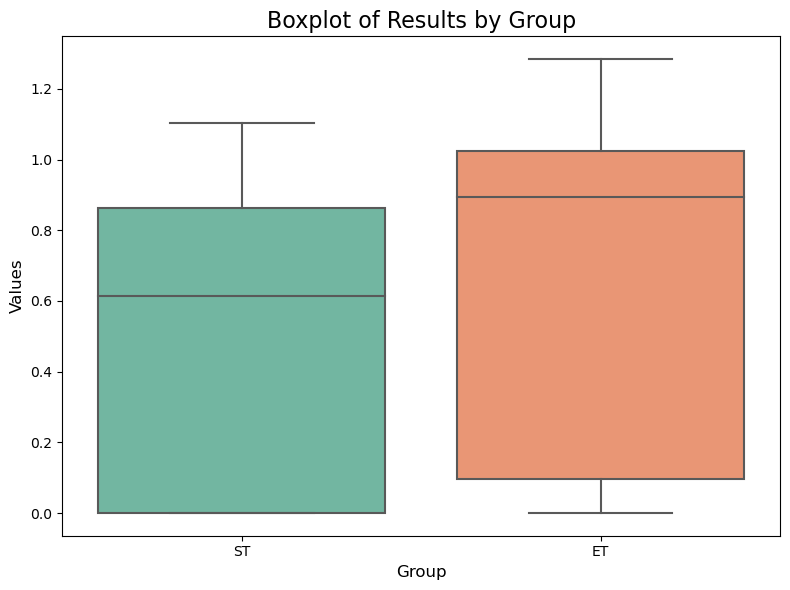

In [34]:
# Assuming your DataFrame is stored as 'df'
df = dev_lastANDtest

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['dev_percent'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_dev = df.groupby('Group')['dev_percent'].apply(find_outliers)

# Print outliers
print(outliers_dev)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y='dev_percent', palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
dev_lastANDtest = dev_lastANDtest.reset_index()

In [36]:
outliers_dev = pd.DataFrame(outliers_dev).reset_index()
outliers_dev_subIds = outliers_dev['subId']

In [37]:
dev_lastANDtest = dev_lastANDtest[~dev_lastANDtest['subId'].isin(outliers_dev_subIds)]

In [310]:

# Convert from wide to long format
dev_lastANDtest_long = dev_lastANDtest.melt(id_vars=["Group", "SubGroup", 'subId'], 
                  value_vars=["last", "dev"], 
                  var_name="Session", 
                  value_name="CorrectResponses")

In [311]:
dev_lastANDtest_long = dev_lastANDtest_long.dropna()

In [312]:
dev_lastANDtest_long.to_csv('dev_lastANDtest_long2.csv')

In [313]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'last':", shapiro(dev_lastANDtest['last']))
print("Shapiro-Wilk test for 'dev':", shapiro(dev_lastANDtest['dev_percent']))


Shapiro-Wilk test for 'last': ShapiroResult(statistic=0.8414628505706787, pvalue=0.0004129623994231224)
Shapiro-Wilk test for 'dev': ShapiroResult(statistic=0.8349383473396301, pvalue=0.0003047532809432596)


### Create plot for DEV results

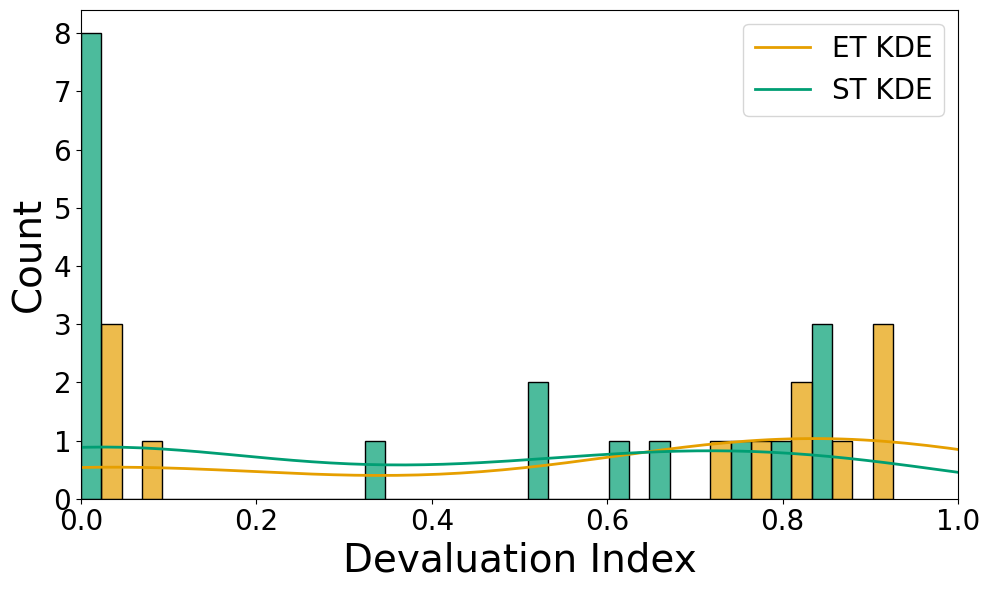

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = dev_lastANDtest

# Define the palette
palette = {"ET": "#E69F00", "ST": "#009E73"}

# Set figure size
plt.figure(figsize=(10, 6))

# Define bins (same for both groups)
num_bins = 20  # Adjust as needed
bin_min = df["dev"].min()
bin_max = df["dev"].max()
bins = np.linspace(bin_min, bin_max, num_bins + 1)  # Ensure equal bin widths

# Create histogram with dodged bars (bars next to each other)
sns.histplot(
    data=df,
    x="dev",
    hue="Group",
    bins=bins,
    multiple="dodge",  # Ensures bars are next to each other
    palette=palette,
    alpha=0.7,  # Transparency to make it clearer
    legend=True
)

# Overlay KDE plots
for group, color in palette.items():
    sns.kdeplot(
        data=df[df["Group"] == group],
        x="dev",
        color=color,
        linewidth=2,
        label=f"{group} KDE"
    )

# Labels and title
plt.xlabel("Devaluation Index", fontsize=28)
plt.ylabel("Count", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(0,1)
# Ensure the legend is visible
plt.legend(title="Group")
plt.legend(fontsize=20)

# Save and show
plt.tight_layout()
plt.savefig("dev_test_histogram_kde_dodged_pilot2.png", dpi=300, bbox_inches="tight")
plt.show()


In [43]:
et_per = (etDevResults[0]/et_last_devResults[0]).dropna()
et_per = et_per.reset_index()
et_per["Group"] = "ET"
st_per = (stDevResults[0]/st_last_devResults[0]).dropna()
st_per = st_per.reset_index()
st_per["Group"] = "ST"

In [44]:
ET_Left = (dev13['dev'])/(last_dev13['last'])
ET_Left = ET_Left.reset_index()
ET_Left["Group"] = "ET_Left"
ST_Left = (dev11['dev']/last_dev11['last'])
ST_Left = ST_Left.reset_index()
ST_Left["Group"] = "ST_Left"
ET_Right = (dev14['dev']/last_dev14['last'])
ET_Right = ET_Right.reset_index()
ET_Right["Group"] = "ET_Right"
ST_Right = (dev12['dev']/last_dev12['last'])
ST_Right = ST_Right.reset_index()
ST_Right["Group"] = "ST_Right"
split = pd.DataFrame([0])
split['subId'] = [1]
split["SubGroup"] = 'Split'


In [45]:
dev_per_hands = pd.concat([ST_Left, ST_Right,ET_Left, ET_Right])
# dev_per_hands = dev_per_hands.drop(columns=['index']).rename(columns={0:'Percent'})

In [46]:
split = split.rename(columns={0:'dev'})
split_ET_Left = pd.concat([dev13[['dev','SubGroup']], split])
split_ET_Right = pd.concat([dev14[['dev','SubGroup']], split])
split_ST_Left = pd.concat([dev11[['dev','SubGroup']], split])
split_ST_Right = pd.concat([dev12[['dev','SubGroup']], split])

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_21913/3119736181.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

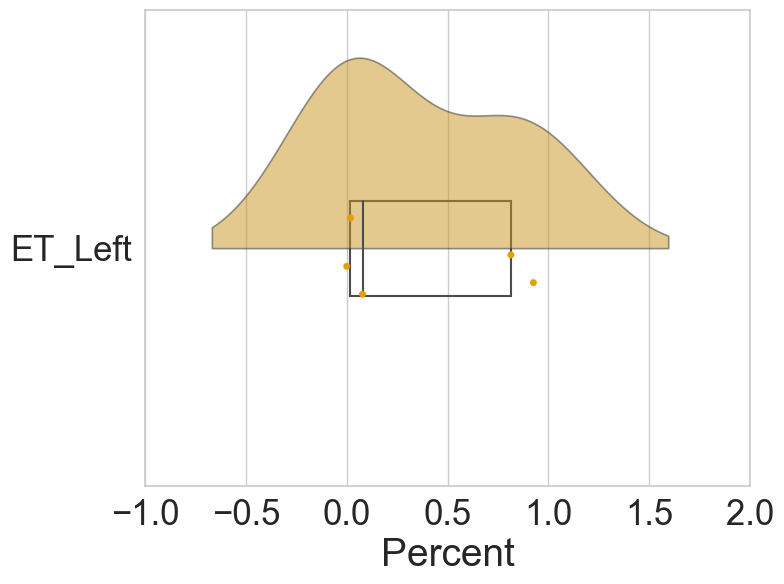

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Left": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 2 - ET Left Devaluation", fontsize=14)
ax.set_xlabel("Percent",fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ET - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_21913/3454756298.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

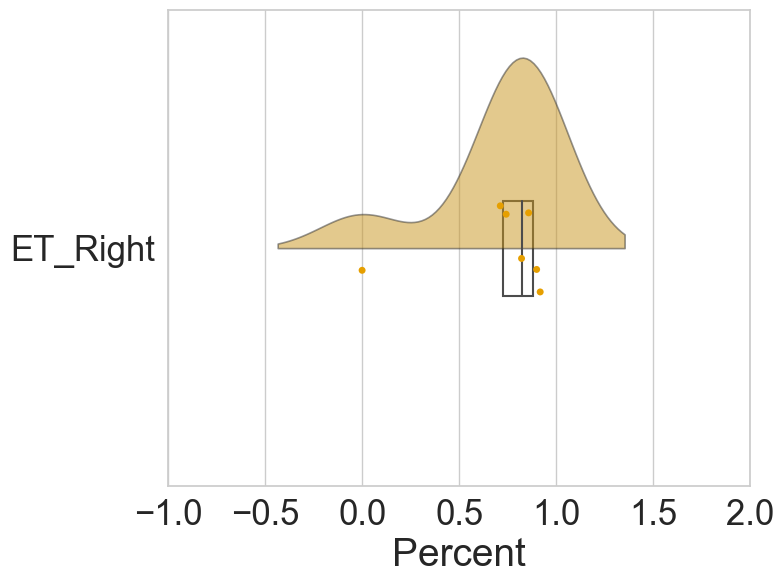

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Right": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 2 - ET Right Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ET - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_21913/1315267790.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

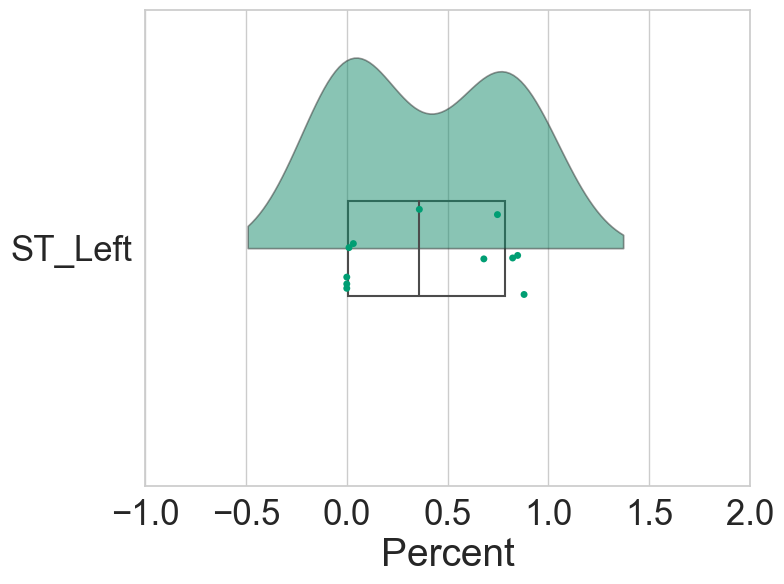

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Left": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 2 - ST Left Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ST - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_21913/1564516955.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

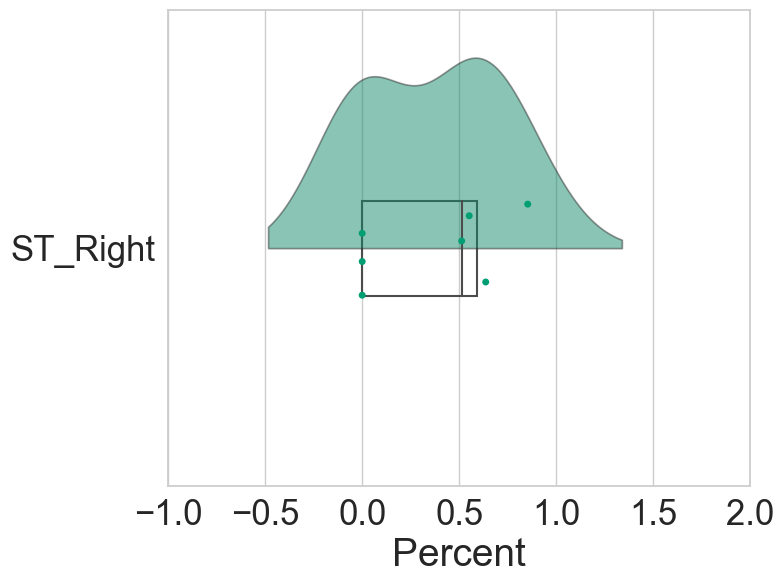

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Right": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 2 - ST Right Devaluation", fontsize=14)
ax.set_xlabel("Percent", fontsize=28)
ax.set_ylabel("")
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.legend_.remove()
ax.set_xlim(-1, 2)
plt.tight_layout()
plt.savefig('ST - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


In [51]:
stDevResults.rename(columns={0: 'percent'}, inplace=True)
etDevResults.rename(columns={0: 'percent'}, inplace=True)

In [52]:
etDevResults.describe()

,percent
count,12.000000
mean,0.566028
std,0.405509
min,0.000000
25%,0.063541
50%,0.778645
75%,0.868939
max,0.925926


In [53]:
stDevResults = stDevResults.reset_index()
stDevResults['Group']= 'ST'
etDevResults = etDevResults.reset_index()
etDevResults['Group']= 'ET'
stDevResults.drop('subId', axis=1, inplace=True)
etDevResults.drop('subId', axis=1, inplace=True)

## Buttons & star tests:

In [54]:
st_count_Results = pd.DataFrame(pd.concat([results_additional[11], results_additional[12]], axis=0)).rename(columns={0:'howManyStars'})
et_count_Results = pd.DataFrame(pd.concat([results_additional[13], results_additional[14]], axis=0)).rename(columns={0:'howManyStars'})
choices11 = pd.DataFrame(results_main[11].allStars.groupby('subId').sum())
choices12 = pd.DataFrame(results_main[12].allStars.groupby('subId').sum())
choices13 = pd.DataFrame(results_main[13].allStars.groupby('subId').sum())
choices14 = pd.DataFrame(results_main[14].allStars.groupby('subId').sum())
st_choice_Results = pd.concat([choices11, choices12], axis=0)
et_choice_Results = pd.concat([choices13, choices14], axis=0)


In [55]:
st_accuracyCount_star = pd.DataFrame(1-(abs(st_choice_Results['allStars']-st_count_Results['howManyStars'])/st_choice_Results['allStars']))
st_accuracyCount_star['Group'] = 'ST'
et_accuracyCount_star = pd.DataFrame(1-(abs(et_choice_Results['allStars']-et_count_Results['howManyStars'])/et_choice_Results['allStars']))
et_accuracyCount_star['Group'] = 'ET'
et_accuracyCount_star = et_accuracyCount_star.drop('64f1e80dd2c8fb647d0add58')

In [56]:
accuracyCount_star = pd.concat([st_accuracyCount_star,et_accuracyCount_star]).rename(columns={'index':'subId'})

#### Outliers stars

Group  subId                   
ET     64f1e80dd2c8fb647d0add5e    0.800000
ST     64f9b20dd2c8fb647d0adfc6    0.294118
Name: 0, dtype: float64


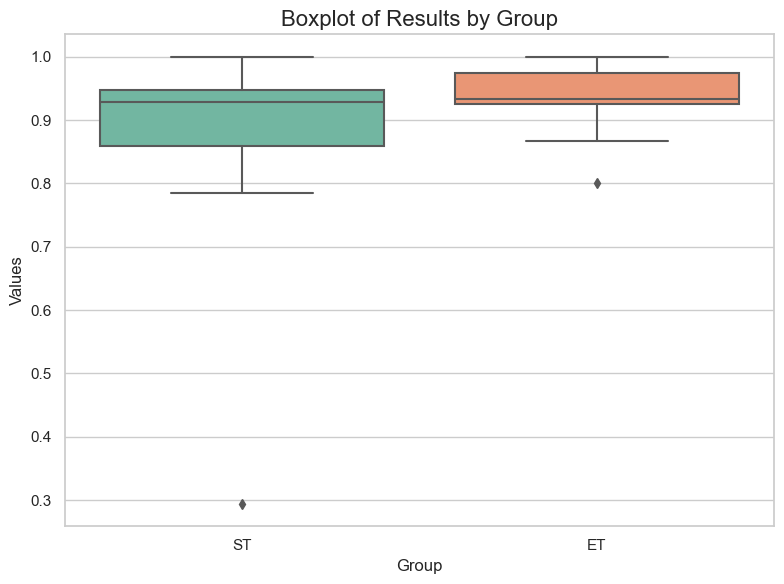

In [57]:
# Assuming your DataFrame is stored as 'df'
df = accuracyCount_star

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y=0, palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()


In [58]:
accuracyCount_star = accuracyCount_star.reset_index().rename(columns={'index':'subId'})

In [59]:
outliers_starts = pd.DataFrame(outliers).reset_index().rename(columns={'level_1':'subId'})
outliersStars_subIds = outliers_starts['subId']

In [60]:
df_stars_cleaned = accuracyCount_star[~accuracyCount_star['subId'].isin(outliersStars_subIds)]

#### Stars stats and plot

In [61]:
df_stars_cleaned.describe()#[df_stars_cleaned['Group']=='ST'].describe()

,0
count,27.000000
mean,0.928651
std,0.059304
min,0.785714
25%,0.899038
50%,0.933333
75%,0.973684
max,1.000000


In [62]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]))
print("Shapiro-Wilk test for 'ET':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9216266870498657, pvalue=0.1573294848203659)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8766887187957764, pvalue=0.119525246322155)


In [63]:
# Extract data for the two groups
group_ST = df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]
group_ET = df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -1.24, p-value = 0.227516
Cohen's d = -0.493


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_21913/1285003.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


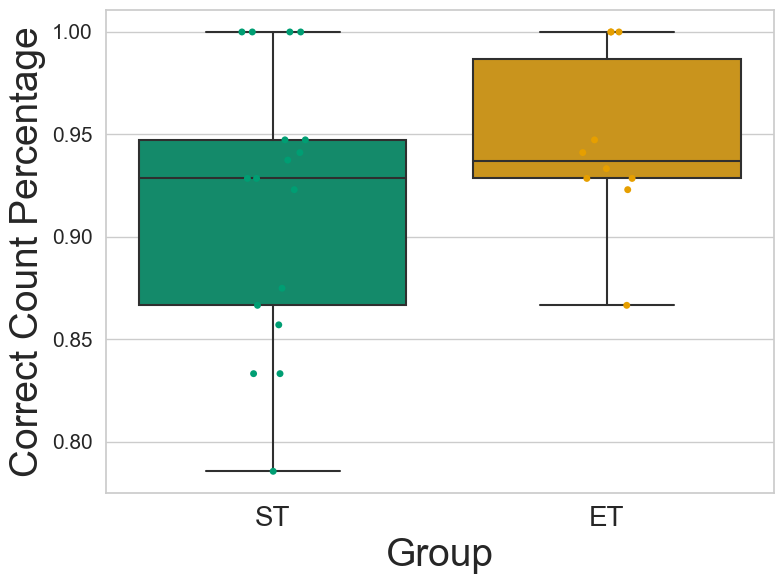

In [64]:

# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y=0, palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Count Percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)

# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


#### Stars and Buttons presses

In [65]:
accuracy_press11 = pd.DataFrame([(results_main[11].correctFirstBluePressStar.groupby('subId').sum()+results_main[11].correctFirstRedPressStar.groupby('subId').sum())/(results_main[11].blueChoiceStar.groupby('subId').sum()+\
results_main[11].redChoiceStar.groupby('subId').sum()), (results_main[11].correctFirstBluePressButtons.groupby('subId').sum()+results_main[11].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[11].blueChoiceButtons.groupby('subId').sum()+\
results_main[11].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
accuracy_press12 = pd.DataFrame([(results_main[12].correctFirstBluePressStar.groupby('subId').sum()+results_main[12].correctFirstRedPressStar.groupby('subId').sum())/(results_main[12].blueChoiceStar.groupby('subId').sum()+\
results_main[12].redChoiceStar.groupby('subId').sum()), (results_main[12].correctFirstBluePressButtons.groupby('subId').sum()+results_main[12].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[12].blueChoiceButtons.groupby('subId').sum()+\
results_main[12].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
accuracy_press13 = pd.DataFrame([(results_main[13].correctFirstBluePressStar.groupby('subId').sum()+results_main[13].correctFirstRedPressStar.groupby('subId').sum())/(results_main[13].blueChoiceStar.groupby('subId').sum()+\
results_main[13].redChoiceStar.groupby('subId').sum()), (results_main[13].correctFirstBluePressButtons.groupby('subId').sum()+results_main[13].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[13].blueChoiceButtons.groupby('subId').sum()+\
results_main[13].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
accuracy_press14 = pd.DataFrame([(results_main[14].correctFirstBluePressStar.groupby('subId').sum()+results_main[14].correctFirstRedPressStar.groupby('subId').sum())/(results_main[14].blueChoiceStar.groupby('subId').sum()+\
results_main[14].redChoiceStar.groupby('subId').sum()), (results_main[14].correctFirstBluePressButtons.groupby('subId').sum()+results_main[14].correctFirstRedPressButtons.groupby('subId').sum())/(results_main[14].blueChoiceButtons.groupby('subId').sum()+\
results_main[14].redChoiceButtons.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Buttons'})
st_accuracyPress_Results = pd.concat([accuracy_press11, accuracy_press12], axis=0)
st_accuracyPress_Results['Group'] = 'ST'
et_accuracyPress_Results = pd.concat([accuracy_press13, accuracy_press14], axis=0)
et_accuracyPress_Results['Group'] = 'ET'
et_accuracyPress_Results = et_accuracyPress_Results.drop('64f1e80dd2c8fb647d0add58')

In [66]:
accuracyPress_Results = pd.concat([st_accuracyPress_Results, et_accuracyPress_Results])

In [67]:
accuracyPress_Results_stars = accuracyPress_Results[['Stars','Group']]
accuracyPress_Results_Buttons = accuracyPress_Results[['Buttons','Group']]

#### Buttons presses

In [68]:
accuracyPress_Results_Buttons[accuracyPress_Results_Buttons['Group']=='ET'].describe()

,Buttons
count,11.000000
mean,0.813047
std,0.059383
min,0.710145
25%,0.789855
50%,0.811594
75%,0.834611
max,0.926471


In [69]:
# Assuming your DataFrame is stored as 'df'
df = accuracyPress_Results_Buttons

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Buttons'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers = df.groupby('Group')['Buttons'].apply(find_outliers)

# Print outliers
print(outliers)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Group  subId                   
ET     64f41b2cd2c8fb647d0adda5    0.710145
       64f1e7cad2c8fb647d0add4d    0.926471
Name: Buttons, dtype: float64


In [70]:
outliers_Buttons_press = pd.DataFrame(outliers).reset_index()
outliersButtonsPress_subIds = outliers_Buttons_press['subId']
accuracyPress_Results_Buttons = accuracyPress_Results_Buttons.reset_index()

In [71]:
df_ButtonsPress_cleaned = accuracyPress_Results_Buttons[~accuracyPress_Results_Buttons['subId'].isin(outliersButtonsPress_subIds)]

In [72]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ST']['Buttons']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ET']['Buttons']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8883966207504272, pvalue=0.036229684948921204)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9299682378768921, pvalue=0.4810442626476288)


In [73]:
# Extract data for the two groups
group_ST = df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ST']['Buttons']
group_ET = df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ET']['Buttons']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 83.00, p-value = 0.938163
Effect size (r) = 0.015


In [74]:
df_ButtonsPress_cleaned[df_ButtonsPress_cleaned['Group']=='ET'].describe()

,Buttons
count,9.000000
mean,0.811878
std,0.038401
min,0.739130
25%,0.811594
50%,0.811594
75%,0.830986
max,0.869565


#### Stars presses

In [75]:
df_stars_cleaned = df_stars_cleaned.set_index('subId')

In [76]:
# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_stars)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Series([], Name: 0, dtype: float64)


In [77]:
outliers_stars = pd.DataFrame(outliers_stars).reset_index()

In [78]:
outliers_Stars_press = pd.DataFrame(outliers_stars).reset_index()
outliersStarsPress_subIds = outliers_stars['subId']
accuracyPress_Results_stars = accuracyPress_Results_stars.reset_index()

In [79]:
df_StarsPress_cleaned = accuracyPress_Results_stars[~accuracyPress_Results_stars['subId'].isin(outliersStarsPress_subIds)]

In [80]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.8729795217514038, pvalue=0.019928736612200737)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8923759460449219, pvalue=0.14888104796409607)


In [81]:
# Extract data for the two groups
group_ST = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST']['Stars']
group_ET = df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ET']['Stars']

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 73.00, p-value = 0.250274
Effect size (r) = 0.213


In [82]:
df_StarsPress_cleaned[df_StarsPress_cleaned['Group']=='ST'].describe()

,Stars
count,18.000000
mean,0.798285
std,0.117668
min,0.463768
25%,0.753623
50%,0.839408
75%,0.880435
max,0.942029


In [83]:
# df_stars_cleaned = df_stars_cleaned.rename(columns={0:'Count'}).set_index('subId').drop(columns=['Group'])
accuracyPress_Results_stars = accuracyPress_Results_stars.rename(columns={'Stars':'Presses'}).set_index('subId')
stars2 = pd.concat([df_stars_cleaned, accuracyPress_Results_stars], axis=1).dropna()
stars2['Pilot'] = 2

In [84]:
stars2.to_csv('stars2.csv')

## RT

In [85]:
def compute_effect_size(U, n1, n2):
    """Compute effect size r using the Z-score method."""
    mean_U = (n1 * n2) / 2  # Expected U
    std_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)  # Standard deviation of U
    Z = (U - mean_U) / std_U  # Compute Z-score
    r = abs(Z) / np.sqrt(n1 + n2)  # Effect size r
    return r, Z

### RT for stars test:

In [86]:
outliersStars = pd.concat([outliersStars_subIds,outliers_stars])

In [87]:
RTs = {}

for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}

    # Filter relevant data
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersStars)]

    # Iterate over rows for BLUE choices
    for row in dfs[i][['subId', 'correctFirstBluePressStar', 'blueChoiceStar']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstBluePressStar in enumerate(row[1].correctFirstBluePressStar):
            valid_choices = [x for x in row[1].blueChoiceStar if x < correctFirstBluePressStar]
            RT_blue_row[ind] = correctFirstBluePressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId}  # Store subId

    # Iterate over rows for RED choices
    for row in dfs[i][['subId', 'correctFirstRedPressStar', 'redChoiceStar']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstRedPressStar in enumerate(row[1].correctFirstRedPressStar):
            valid_choices = [x for x in row[1].redChoiceStar if x < correctFirstRedPressStar]
            RT_red_row[ind] = correctFirstRedPressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId}  # Store subId

    # Convert to DataFrame
    RTs[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                     for key, subdict in RT.items() 
                                     for subkey, values in subdict.items()}, 
                                     orient='index')

    # Reset index to make 'Color' and 'RowIndex' columns
    RTs[i].reset_index(inplace=True)
    RTs[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)

    # Ensure 'subId' is set as an index or a column
    RTs[i] = RTs[i].set_index('subId')

    # Expand dictionary values into separate columns
    RTs[i] = pd.concat([RTs[i], RTs[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

    # Drop unnecessary nested dictionary column
    RTs[i].drop(columns=[0], inplace=True, errors='ignore')



In [88]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [90]:
mean_RTs = {}

for grp, RT in RTs.items():
    # Compute mean RTs while keeping 'subId'
    mean_df = RT.groupby(["subId", "Color"])["RTs"].apply(lambda x: 
        pd.Series([item for sublist in x.dropna() for item in to_list(sublist)]).mean()
    ).unstack()  # Convert 'Color' categories into separate columns

    # Store the result
    mean_RTs[grp] = mean_df.reset_index()  # Ensure 'subId' is a column


In [168]:
BandRST = pd.concat([mean_RTs[11], mean_RTs[12]]).reset_index()
BandRST["Group"]="ST"
BandRET = pd.concat([mean_RTs[13], mean_RTs[14]]).reset_index()
BandRET["Group"]="ET"
BandR = pd.concat([BandRST,BandRET])
BandR = BandR.drop(columns = "index")
BandR['Hand_mean'] = BandR[['Blue', 'Red']].mean(axis=1)

In [170]:
BandR = BandR.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['Hand_mean'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [171]:
# Assuming your DataFrame is stored as 'df'
df = BandR

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_stars = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Series([], Name: MeanRT, dtype: float64)


In [172]:
outliers_RT_Stars = pd.DataFrame(outliers_RT_stars).reset_index()
outliers_RT_Stars_subIds = outliers_RT_Stars['level_1']

In [173]:
df_RT_Stars_cleaned = BandR[~BandR['subId'].isin(outliers_RT_Stars_subIds)]

In [174]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR[BandR['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandR[BandR['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9750195145606995, pvalue=0.884909451007843)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8990578651428223, pvalue=0.1800120621919632)


In [308]:
from scipy.stats import ttest_ind
import numpy as np

# Extract data for the two groups
group_ST = BandR[BandR['Group']=='ST']['MeanRT'].dropna()
group_ET = BandR[BandR['Group']=='ET']['MeanRT'].dropna()

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Welch-Satterthwaite degrees of freedom
df = (std_ST**2/n_ST + std_ET**2/n_ET)**2 / (
    (std_ST**2/n_ST)**2/(n_ST-1) + (std_ET**2/n_ET)**2/(n_ET-1)
)

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t{df:.2f} = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t22.83 = 0.52, p-value = 0.606926
Cohen's d = 0.199


In [309]:
df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].describe()

count     11.000000
mean     755.667779
std       53.699433
min      671.933333
25%      713.123948
50%      760.802299
75%      807.368998
max      816.683448
Name: MeanRT, dtype: float64

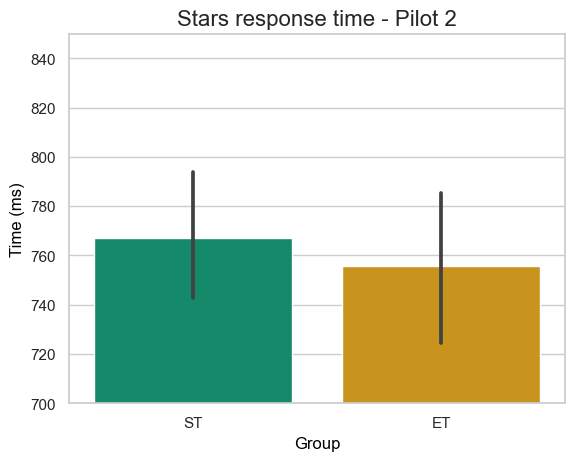

In [178]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Stars_cleaned, x="Group", y="MeanRT", palette=custom_palette)

# Set axis limits
plt.ylim(700, 850)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Stars response time - Pilot 2', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_stars.png")

# Show the plot
plt.show()


In [179]:
df_RT_Stars_cleaned['Pilot'] = 2
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned2.csv')

### RT for buttons

In [278]:
RTs_Buttons = {}

for i in range(11, 15):
    RT = {'subId':{},'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersButtonsPress_subIds)]
    for row in dfs[i][['subId','correctFirstBluePressButtons', 'blueChoiceButtons']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        subId = row[1].subId
        counter = 0
        for correctFirstBluePressButtons in row[1].correctFirstBluePressButtons:
            choices_before_press = [x for x in row[1].blueChoiceButtons if x<correctFirstBluePressButtons]
            # print(correctFirstRedPressButtons, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressButtons - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
            RT['subId'][row[0]] = subId
            
    for row in dfs[i][['subId','correctFirstRedPressButtons', 'redChoiceButtons']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        counter = 0
        for correctFirstRedPressButtons in row[1].correctFirstRedPressButtons:
            choices_before_press = [x for x in row[1].redChoiceButtons if x<correctFirstRedPressButtons]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressButtons - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
            RT['subId'][row[0]] = subId

    # Convert nested dictionary to DataFrame
    RTs_Buttons[i] = pd.DataFrame(RT)

# Reset index so 'Color' and 'RowIndex' become columns
RTs_Buttons[i].reset_index(inplace=True)
RTs_Buttons[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
RTs_Buttons[i] = RTs_Buttons[i].set_index('subId')
# Expand dictionary values (RTs, subId, createdAt) into separate columns
RTs_Buttons[i] = pd.concat([RTs_Buttons[i], RTs_Buttons[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

# Drop the original column that stored the dictionaries (it has been expanded)
RTs_Buttons[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [279]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [283]:
df_means = {}

for i in range(11, 15):

    df = RTs_Buttons[i].copy()

    # Make sure subId is always a regular column
    if 'subId' not in df.columns:
        df = df.reset_index()

    # Remove old row-index column if it exists
    if 'index' in df.columns:
        df = df.drop(columns='index')

    df_means[i] = pd.DataFrame()

    df_means[i]['subId'] = df['subId'].values

    df_means[i]['MeanRT_Blue'] = df['Blue'].apply(
        lambda x: np.mean(x) if isinstance(x, list) else np.nan
    ).values

    df_means[i]['MeanRT_Red'] = df['Red'].apply(
        lambda x: np.mean(x) if isinstance(x, list) else np.nan
    ).values

    df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)

    df_means[i]['Group'] = 'ST' if i in range(11, 13) else 'ET'
    df_means[i]['Run'] = i

df_buttons_mean_all = pd.concat(df_means.values(), ignore_index=True)

In [285]:
df_buttons_mean_all.head()

,subId,MeanRT_Blue,MeanRT_Red,Mean_All,Group,Run
0,64f9b20dd2c8fb647d0adfc2,818.035714,808.413793,813.224754,ST,11
1,64f9b20dd2c8fb647d0adfbd,736.037037,767.531250,751.784144,ST,11
2,64f9b20dd2c8fb647d0adfc4,745.500000,832.720000,789.110000,ST,11
3,64f9b20dd2c8fb647d0adfc6,788.291667,784.333333,786.312500,ST,11
4,64f9b20dd2c8fb647d0adfbf,754.971429,748.333333,751.652381,ST,11


In [288]:
BandR_buttons = df_buttons_mean_all[['subId','Group','Mean_All']]

In [292]:
BandR_buttons = BandR_buttons.rename(columns={'Mean_All':'Response time'})
BandR_buttons.head()

,subId,Group,Response time
0,64f9b20dd2c8fb647d0adfc2,ST,813.224754
1,64f9b20dd2c8fb647d0adfbd,ST,751.784144
2,64f9b20dd2c8fb647d0adfc4,ST,789.110000
3,64f9b20dd2c8fb647d0adfc6,ST,786.312500
4,64f9b20dd2c8fb647d0adfbf,ST,751.652381


In [293]:
# Assuming your DataFrame is stored as 'df'
df = BandR_buttons

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_buttons = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Series([], Name: MeanRT, dtype: float64)


In [294]:
outliers_RT_Buttons = pd.DataFrame(outliers_RT_buttons).reset_index()
outliers_RT_Buttons_subIds = outliers_RT_Buttons['level_1']

In [296]:
BandR_buttons.head()

,subId,Group,Response time
0,64f9b20dd2c8fb647d0adfc2,ST,813.224754
1,64f9b20dd2c8fb647d0adfbd,ST,751.784144
2,64f9b20dd2c8fb647d0adfc4,ST,789.110000
3,64f9b20dd2c8fb647d0adfc6,ST,786.312500
4,64f9b20dd2c8fb647d0adfbf,ST,751.652381


In [297]:
df_RT_Buttons_cleaned = BandR_buttons[~BandR_buttons['subId'].isin(outliers_RT_Buttons_subIds)]

In [301]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR_buttons[BandR_buttons['Group']=='ST']['Response time'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandR_buttons[BandR_buttons['Group']=='ET']['Response time'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9551600217819214, pvalue=0.5115454792976379)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.862035870552063, pvalue=0.1008935198187828)


In [306]:
# Extract data for the two groups
group_ST = BandR_buttons[BandR_buttons['Group']=='ST']['Response time']
group_ET = BandR_buttons[BandR_buttons['Group']=='ET']['Response time']
# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Welch-Satterthwaite degrees of freedom
df = (std_ST**2/n_ST + std_ET**2/n_ET)**2 / (
    (std_ST**2/n_ST)**2/(n_ST-1) + (std_ET**2/n_ET)**2/(n_ET-1)
)

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t{df:.2f} = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t16.68 = 1.10, p-value = 0.281400
Cohen's d = 0.449


In [314]:
group_ST.describe()

count     18.000000
mean     767.023628
std       58.858993
min      657.889881
25%      719.843132
50%      762.295211
75%      812.929167
max      889.160417
Name: MeanRT, dtype: float64

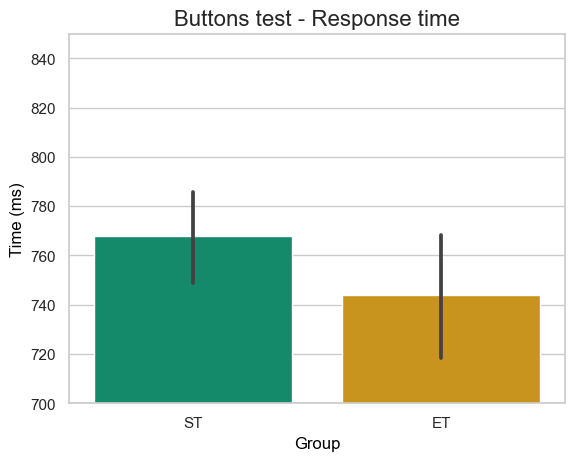

<Figure size 640x480 with 0 Axes>

In [112]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=BandR_buttons, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(700, 850)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Buttons test - Response time', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_buttons.png")

# Show the plot
plt.show()

plt.savefig("response_time_buttons.png")

### RT training

In [113]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_RTs(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return [item for item in lst if isinstance(item, int) and item > 180000]

In [114]:
dfs_for_RT_blue = {}
dfs_for_RT_red = {}
dfs_for_RT = {}

for i in range (13, 15):
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].drop(columns=['subId'])

    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['subId','createdAt'])

    
for i in range (11, 13):    
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by=['subId', 'createdAt'])
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId', as_index=True).first()
    
    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId', as_index=True).first()
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['createdAt'])

for i in range (11, 15):    
    dfs_for_RT[i] = pd.concat([dfs_for_RT_blue[i], dfs_for_RT_red[i]], axis=1).reset_index().rename(columns={'index': 'subId'})

In [115]:
# Remove the first element from each list in the 'correctFirstBluePress' column for all rows
dfs_for_RT[12]['correctFirstBluePress'] = dfs_for_RT[12]['correctFirstBluePress'].apply(
    lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
)


In [116]:
RTs_general = {}
Ts_general = {}
for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}
    RT_df = dfs_for_RT[i]
    for row in RT_df[['subId', 'createdAt', 'correctFirstBluePress', 'blueChoice']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt
        
        for ind, correctFirstBluePress in enumerate(sorted(row[1].correctFirstBluePress)):
            row[1].blueChoice = sorted(row[1].blueChoice) 
            RT_blue_row[ind] = correctFirstBluePress - [x for x in row[1].blueChoice if x < correctFirstBluePress][-1]
        
        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId, 'createdAt': createdAt}

    for row in RT_df[['subId', 'createdAt', 'correctFirstRedPress', 'redChoice']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt

        for ind, correctFirstRedPress in enumerate(sorted(row[1].correctFirstRedPress)):
            RT_red_row[ind] = correctFirstRedPress - [x for x in row[1].redChoice if x < correctFirstRedPress][-1]
        
        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId, 'createdAt': createdAt}

        # Convert nested dictionary to DataFrame
        RTs_general[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                                 for key, subdict in RT.items() 
                                                 for subkey, values in subdict.items()}, 
                                                 orient='index')

        # Reset index so 'Color' and 'RowIndex' become columns
        RTs_general[i].reset_index(inplace=True)
        RTs_general[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
        RTs_general[i] = RTs_general[i].set_index('subId')
        # Expand dictionary values (RTs, subId, createdAt) into separate columns
        RTs_general[i] = pd.concat([RTs_general[i], RTs_general[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

        # Drop the original column that stored the dictionaries (it has been expanded)
        RTs_general[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [117]:
df_reset = {}
df_means = {}

for i in range (11,15):
    # Reset index to ensure 'subId' and 'Color' are columns
    df_reset[i] = RTs_general[i].reset_index().dropna()

    # Compute the mean RTs for each combination of 'subId' and 'Color'
    df_means[i] = df_reset[i].groupby(['subId', 'Color'])['RTs'].apply(lambda x: np.mean(x.values[0]) if isinstance(x.values[0], list) else np.nan).unstack()

    # Rename columns for clarity
    df_means[i].columns = ['MeanRT_Blue', 'MeanRT_Red']
    # df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)
    if i in range (11,13):
        df_means[i]['Group'] = 'ST'
    else:
        df_means[i]['Group'] = 'ET'

In [118]:
df_means = pd.concat([df_means[11],df_means[12],df_means[13],df_means[14]])

In [119]:
# Reset index to make 'subId' a column before melting
RT_means_training = df_means.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['MeanRT_Blue', 'MeanRT_Red'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [120]:
# Assuming your DataFrame is stored as 'df'
df = RT_means_training

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_training = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_training)

Series([], Name: MeanRT, dtype: float64)


In [121]:
outliers_RT_training

Series([], Name: MeanRT, dtype: float64)

In [122]:
outliers_RT_training = pd.DataFrame(outliers_RT_training).reset_index()
outliers_RT_training_subIds = outliers_RT_training['level_1']
df_means = RT_means_training.reset_index()

In [123]:
df_RT_training_cleaned = RT_means_training[~RT_means_training['subId'].isin(outliers_RT_training_subIds)]

In [124]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(RT_means_training[RT_means_training['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(RT_means_training[RT_means_training['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.947388768196106, pvalue=0.08654331415891647)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8774644732475281, pvalue=0.015933876857161522)


In [125]:
df_RT_Stars_cleaned

,subId,Group,Color,MeanRT,Pilot
0,64f9b20dd2c8fb647d0adfbd,ST,Blue,722.729730,2
1,64f9b20dd2c8fb647d0adfbe,ST,Blue,738.764706,2
2,64f9b20dd2c8fb647d0adfbf,ST,Blue,706.064516,2
3,64f9b20dd2c8fb647d0adfc0,ST,Blue,744.625000,2
4,64f9b20dd2c8fb647d0adfc1,ST,Blue,865.133333,2
5,64f9b20dd2c8fb647d0adfc2,ST,Blue,833.500000,2
6,64f9b20dd2c8fb647d0adfc3,ST,Blue,675.208333,2
7,64f9b20dd2c8fb647d0adfc4,ST,Blue,812.777778,2
8,64f9b20dd2c8fb647d0adfc6,ST,Blue,705.468750,2
9,64f9b20dd2c8fb647d0adfc7,ST,Blue,772.576923,2


In [126]:
RT_means_training['Pilot'] = 2
df_RT_Stars_cleaned['Pilot'] = 2
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned2.csv')

In [127]:
df_RT_Stars_cleaned = df_RT_Stars_cleaned.rename(columns={'Response time':'MeanRT'})
df_RT_Stars_cleaned['step'] = 'Stars'
RT_means_training['step'] = 'Training'
#,RT_means_training['MeanRT']

In [128]:
rt_stars_training = pd.concat([df_RT_Stars_cleaned,RT_means_training])

In [129]:
rt_stars_training

,subId,Group,Color,MeanRT,Pilot,step
0,64f9b20dd2c8fb647d0adfbd,ST,Blue,722.729730,2,Stars
1,64f9b20dd2c8fb647d0adfbe,ST,Blue,738.764706,2,Stars
2,64f9b20dd2c8fb647d0adfbf,ST,Blue,706.064516,2,Stars
3,64f9b20dd2c8fb647d0adfc0,ST,Blue,744.625000,2,Stars
4,64f9b20dd2c8fb647d0adfc1,ST,Blue,865.133333,2,Stars
...,...,...,...,...,...,...
51,64f1e7cad2c8fb647d0add49,ET,MeanRT_Red,762.250000,2,Training
52,64f1e7cad2c8fb647d0add4f,ET,MeanRT_Red,747.190476,2,Training
53,64f1e7cad2c8fb647d0add50,ET,MeanRT_Red,808.868421,2,Training
54,64f1e7f3d2c8fb647d0add53,ET,MeanRT_Red,644.756757,2,Training


In [130]:
# rt_stars_training = rt_stars_training.drop(columns=['index','Pilot','subId','Color'])
rt_stars_training['Pilot'] = 2
rt_stars_training.to_csv('rt_stars_training2.csv')

### RT for devaluation test

In [324]:
RTs_Dev = {}

for i in range(11, 15):

    RT = {'subId': {}, 'Blue': {}, 'Red': {}}

    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])].copy()
    # dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_Dev['subId'])]

    for idx, row in dfs[i][['subId', 'correctFirstBluePressDevtest', 'blueChoiceDev']].dropna().iterrows():
        RT_blue_row = []

        for correctFirstBluePressDev in row.correctFirstBluePressDevtest:
            choices_before_press = [
                x for x in row.blueChoiceDev
                if x < correctFirstBluePressDev
            ]

            if len(choices_before_press) > 0:
                RT_blue_row.append(correctFirstBluePressDev - choices_before_press[-1])

        if len(RT_blue_row) > 0:
            RT['subId'][idx] = row.subId
            RT['Blue'][idx] = RT_blue_row

    for idx, row in dfs[i][['subId', 'correctFirstRedPressDevtest', 'redChoiceDev']].dropna().iterrows():
        RT_red_row = []

        for correctFirstRedPressDev in row.correctFirstRedPressDevtest:
            choices_before_press = [
                x for x in row.redChoiceDev
                if x < correctFirstRedPressDev
            ]

            if len(choices_before_press) > 0:
                RT_red_row.append(correctFirstRedPressDev - choices_before_press[-1])

        if len(RT_red_row) > 0:
            RT['subId'][idx] = row.subId
            RT['Red'][idx] = RT_red_row

    RTs_Dev[i] = pd.DataFrame(RT).reset_index(drop=True)


In [325]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [326]:
mean_RTs_Dev = {}

for grp, RT in RTs_Dev.items():
    mean_RTs_Dev[grp] = pd.DataFrame({
        'subId': RT['subId'],
        'Group': 'ST' if grp in [11, 12] else 'ET',
        'Blue': RT['Blue'].apply(lambda x: np.mean(to_list(x)) if len(to_list(x)) > 0 else np.nan),
        'Red': RT['Red'].apply(lambda x: np.mean(to_list(x)) if len(to_list(x)) > 0 else np.nan)
    })


long_parts = []

for grp, df_grp in mean_RTs_Dev.items():
    group_label = 'ST' if grp in [11, 12] else 'ET'
    
    if grp in [11, 13]:
        dev_col = 'Red'
        nondev_col = 'Blue'
    elif grp in [12, 14]:
        dev_col = 'Blue'
        nondev_col = 'Red'
    else:
        continue

    dev_df = df_grp[['subId', dev_col]].copy()
    dev_df = dev_df.rename(columns={dev_col: 'RT'})
    dev_df['Condition'] = 'Dev'
    dev_df['Group'] = group_label
    dev_df['OriginalGroup'] = grp

    nondev_df = df_grp[['subId', nondev_col]].copy()
    nondev_df = nondev_df.rename(columns={nondev_col: 'RT'})
    nondev_df['Condition'] = 'nonDev'
    nondev_df['Group'] = group_label
    nondev_df['OriginalGroup'] = grp

    # keep only participants with both Dev and nonDev RTs
    valid_subs = set(dev_df.dropna(subset=['RT'])['subId']).intersection(
        set(nondev_df.dropna(subset=['RT'])['subId'])
    )

    dev_df = dev_df[dev_df['subId'].isin(valid_subs)]
    nondev_df = nondev_df[nondev_df['subId'].isin(valid_subs)]

    long_parts.extend([dev_df, nondev_df])


BandR_long = pd.concat(long_parts, ignore_index=True).dropna(subset=['RT'])

BandR_long.head()

,subId,RT,Condition,Group,OriginalGroup
0,64f9b20dd2c8fb647d0adfbf,741.741573,Dev,ST,11
1,64f9b20dd2c8fb647d0adfbd,725.544304,Dev,ST,11
2,64f9b20dd2c8fb647d0adfc8,733.904110,Dev,ST,11
3,64f9b20dd2c8fb647d0adfc1,882.000000,Dev,ST,11
4,64f9b20dd2c8fb647d0adfc2,789.391892,Dev,ST,11


In [331]:
BandR_long.to_csv("df_long_dev_RT2.csv", index=False)

In [328]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST-dev':", shapiro(BandR_long.query("Group == 'ST' and Condition == 'Dev'")['RT'])) 
print("Shapiro-Wilk test for 'ET-dev':", shapiro(BandR_long.query("Group == 'ET' and Condition == 'Dev'")['RT']))
print("Shapiro-Wilk test for 'ST-nondev':", shapiro(BandR_long.query("Group == 'ST' and Condition == 'nonDev'")['RT'])) 
print("Shapiro-Wilk test for 'ET-nondev':", shapiro(BandR_long.query("Group == 'ET' and Condition == 'nonDev'")['RT']))

Shapiro-Wilk test for 'ST-dev': ShapiroResult(statistic=0.952575147151947, pvalue=0.6748830080032349)
Shapiro-Wilk test for 'ET-dev': ShapiroResult(statistic=0.9239648580551147, pvalue=0.39121267199516296)
Shapiro-Wilk test for 'ST-nondev': ShapiroResult(statistic=0.7583651542663574, pvalue=0.0032722216565161943)
Shapiro-Wilk test for 'ET-nondev': ShapiroResult(statistic=0.8952630758285522, pvalue=0.19421418011188507)
